**IMPORT LIBRARIES**

In [571]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [572]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**LOAD DATASET**

In [573]:
df = pd.read_csv('car data.csv')

**SHOW DATASET**

In [574]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


**DATASET INFORMATION**

In [575]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [576]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [577]:
# Check Missing Values
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [578]:
# Remove Outliers
df = df[df['Selling_Price'] < 15]

**ENCODING CATEGORICAL DATA**

In [579]:
from sklearn.preprocessing import LabelEncoder

# Create Encoders
car_encoder = LabelEncoder()
fuel_encoder = LabelEncoder()
seller_encoder = LabelEncoder()
trans_encoder = LabelEncoder()

# Fit Encoders
df['Car_Name'] = car_encoder.fit_transform(df['Car_Name'])

df['Fuel_Type'] = fuel_encoder.fit_transform(df['Fuel_Type'])

df['Selling_type'] = seller_encoder.fit_transform(df['Selling_type'])

df['Transmission'] = trans_encoder.fit_transform(df['Transmission'])

/tmp/ipykernel_9935/3529174392.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Car_Name'] = car_encoder.fit_transform(df['Car_Name'])
/tmp/ipykernel_9935/3529174392.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fuel_Type'] = fuel_encoder.fit_transform(df['Fuel_Type'])
/tmp/ipykernel_9935/3529174392.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

**CORRELATION HEATMAP**

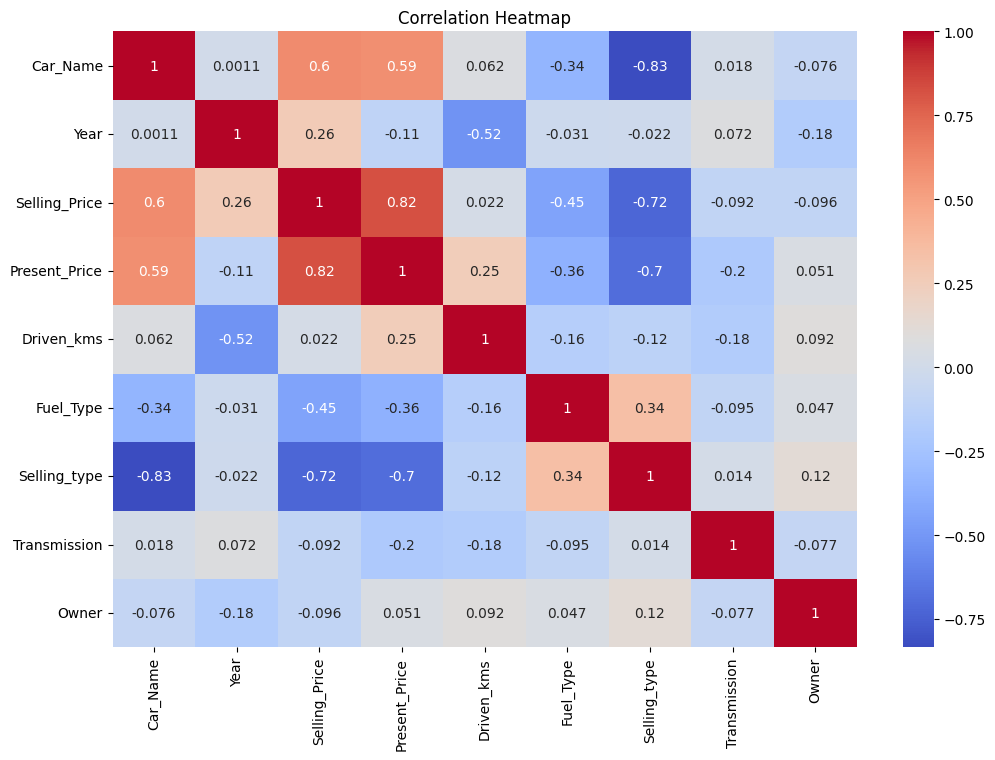

In [580]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

**FEATURE SELECTION**

In [581]:
# Feature Selection
# Input Features (X)
X = df.drop(['Selling_Price'], axis=1)

In [582]:
X

,Car_Name,Year,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,89,2014,5.59,27000,2,0,1,0
1,92,2013,9.54,43000,1,0,1,0
2,68,2017,9.85,6900,2,0,1,0
3,95,2011,4.15,5200,2,0,1,0
4,91,2014,6.87,42450,1,0,1,0
...,...,...,...,...,...,...,...,...
296,69,2016,11.60,33988,1,0,1,0
297,66,2015,5.90,60000,2,0,1,0
298,69,2009,11.00,87934,2,0,1,0
299,69,2017,12.50,9000,1,0,1,0


In [583]:
# Target Variable (y)
y = df['Selling_Price']

In [584]:
y

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60
...,...
296,9.50
297,4.00
298,3.35
299,11.50


**TRAIN TEST SPLIT**

In [585]:
# Split Dataset
# 80% training ke liye
# 20% testing ke liye
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**TRAIN RANDOM FOREST MODEL**

In [592]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

**PREDICTION**

In [588]:
# Predict Prices
y_pred = model.predict(X_test)
print(y_pred)

[ 7.70982   0.53922   7.58586   2.441595  0.42008   7.133705  2.918625
  0.31458   6.738975  6.197885  8.24405   6.575765  0.76214   6.5306
  7.530885  3.87385   8.023765  9.770335 11.273355  5.55512   5.228725
  6.914075  0.743395  9.16271   5.321855  5.992595  0.543585  0.46381
  1.13994   5.26996   1.12691   0.196375  0.556625  6.045045  0.172035
  0.40843   5.72056   0.468345  4.866175  0.632635  0.359615  8.07904
  0.378955  0.472855  3.844375  2.8897    2.747675  0.422275  0.578885
  0.20775   5.068125  4.070125  1.11179   3.440625  0.24773   0.181025
  4.80155   6.112415]


**MODEL EVALUATION**

In [589]:
# Model Evaluation
# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.46829163793103684


In [590]:
# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.5235850120392311


In [591]:
# R2 Score
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9538919674261389


**ACTUAL VS PREDICTED VISUALIZATION**

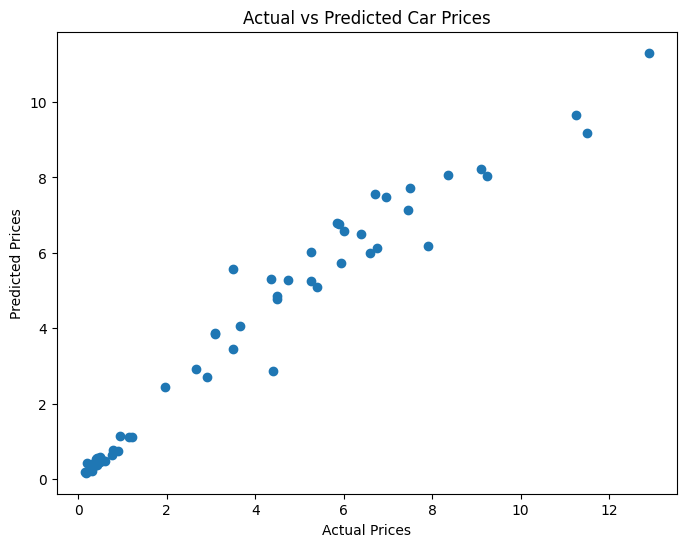

In [566]:
# Visualization
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Car Prices")

plt.show()

**# FEATURE IMPORTANCE**

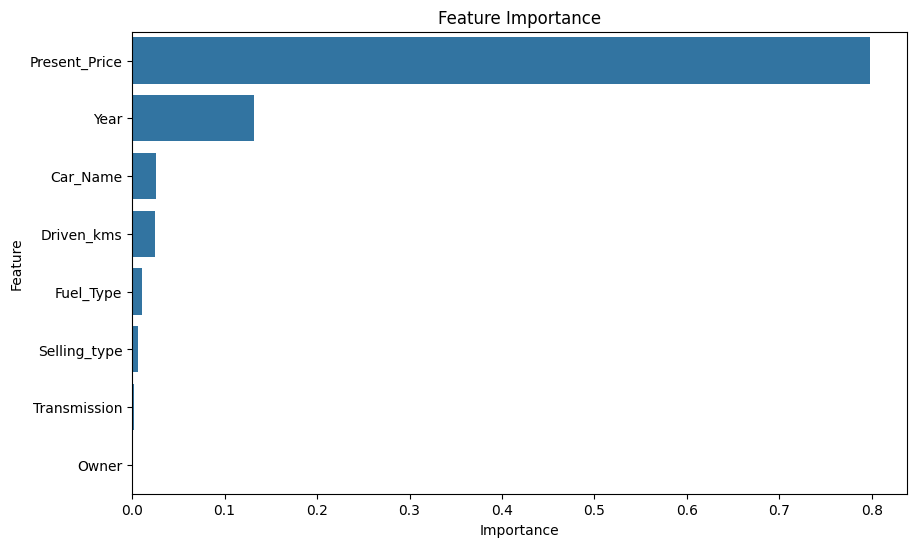

In [567]:
importance = model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")

plt.show()

**TEST ON NEW CAR SAMPLE**

In [593]:
car_name = car_encoder.inverse_transform([20])

print(car_name[0])

Hero Extreme


In [594]:
car_name = 'Hero Extreme'

encoded_car = car_encoder.transform([car_name])[0]

sample_df = pd.DataFrame([{

    'Car_Name': encoded_car,

    'Year': 2014,

    'Present_Price': 0.787,

    'Driven_kms': 15000,

    'Fuel_Type': 2,  #Petrol=1,Diesel=2

    'Selling_type': 1, #Individual=1, Individual=2

    'Transmission': 1, #Manual=1,Automatic=2

    'Owner': 0
}])

# sample_scaled = scaler.transform(sample_df)

predicted_price = model.predict(sample_df)

print(f"Predicted Price: {predicted_price[0]:.2f} Lakhs")

Predicted Price: 0.57 Lakhs


**Checking  Selling_Price**

In [570]:
df.sample()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
146,20,2014,0.55,0.787,15000,2,1,1,0
